In [21]:
# Importing NumPy for array operations
import numpy as np

# Importing Matplotlib for plotting images and graphs
import matplotlib.pyplot as plt

# Importing TensorFlow and Keras for deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [ ]:
# Loading the MNIST dataset directly from Keras
# It automatically splits into training and testing data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("shape of training images:", x_train.shape)
print("shape of training labels:", y_train.shape)
print("shape of testing images: ", x_test.shape)
print("shape of testing labels: ", y_test.shape)

print("Total training samples:", len(x_train))
print("Total testing samples: ", len(x_test))

shape of training images: (60000, 28, 28)
shape of training labels: (60000,)
shape of testing images:  (10000, 28, 28)
shape of testing labels:  (10000,)
Total training samples: 60000
Total testing samples:  10000


Labels of the first 10 images: [5 0 4 1 9 2 1 3 1 4]


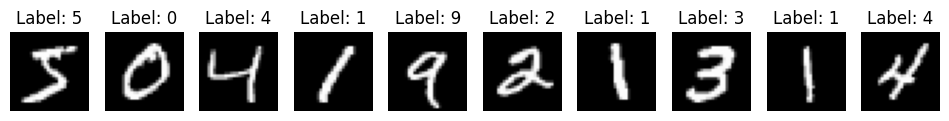

In [41]:
print("Labels of the first 10 images:", y_train[:10])
# Plotting the first 10 images from training set
plt.figure(figsize=(12, 3))

for i in range(10):
    plt.subplot(1, 10, i + 1)           # Creating a subplot for each image
    plt.imshow(x_train[i], cmap='gray') # Displaying image in grayscale
    plt.title(f"Label: {y_train[i]}")   # Showing the label on top
    plt.axis('off')                      # Hiding axes

In [ ]:
#pixel values before normalization
print("min:", x_train.min())
print("max:", x_train.max())

Pixel value range BEFORE normalization:
Min pixel value: 0
Max pixel value: 255



Reshape images – CNN expects input shape (height, width, channels). Since MNIST is grayscale, channels = 1. So I reshape (28, 28) → (28, 28, 1)

In [ ]:
#[0, 255] to [0, 1]

x_train = x_train / 255.0
x_test  = x_test  / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

print(x_train.shape)
print(x_test.shape)

print()
print("Pixel value range AFTER normalization:")
print("min pixel value:", x_train.min())
print("max pixel value:", x_train.max())

(60000, 28, 28, 1)
(10000, 28, 28, 1)

Pixel value range AFTER normalization:
Min pixel value: 0.0
Max pixel value: 9.274683492658337e-13


CNN Architecture:

| Layer | Type | Details |
|---|---|---|
| 1 | Conv2D | 32 filters, 3×3 kernel, ReLU |
| 2 | MaxPooling2D | 2×2 pool |
| 3 | Conv2D | 64 filters, 3×3 kernel, ReLU |
| 4 | MaxPooling2D | 2×2 pool |
| 5 | Flatten | Converts 2D to 1D |
| 6 | Dense | 64 neurons, ReLU |
| 7 | Dense (Output) | 10 neurons, Softmax |

- **Conv2D** – Extracts features from images using filters
- **MaxPooling2D** – Reduces image size while keeping important features
- **Flatten** – Converts 2D feature maps into a 1D vector
- **Dense** – Fully connected layer for classification
- **Softmax** – Gives probability for each of the 10 digit classes

In [ ]:
model = models.Sequential()


model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

# First MaxPooling Layer: reduces image size from 26x26 to 13x13
model.add(layers.MaxPooling2D((2, 2)))

# Second Convolutional Layer: 64 filters, each of size 3x3
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Second MaxPooling Layer: reduces image size further
model.add(layers.MaxPooling2D((2, 2)))

# Flatten Layer: converts 2D feature maps to 1D vector
model.add(layers.Flatten())

# Fully Connected (Dense) Layer: 64 neurons
model.add(layers.Dense(64, activation='relu'))

# Output Layer: 10 neurons (one for each digit 0-9)
# Softmax gives probability for each class
model.add(layers.Dense(10, activation='softmax'))

# Compiling the model
# adam optimizer adjusts learning rate automatically
# sparse_categorical_crossentropy is used when labels are integers (0-9)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

C:\Users\archit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# x_train, y_train = training images and their labels
# epochs = number of times the model trains on the full dataset
# batch_size = number of samples processed before updating weights
# validation_data = used to check performance after each epoch
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test, y_test)
)

print("\nTraining complete!")

Starting Training...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9521 - loss: 0.1534 - val_accuracy: 0.9820 - val_loss: 0.0607
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9844 - loss: 0.0491 - val_accuracy: 0.9809 - val_loss: 0.0569
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9899 - loss: 0.0332 - val_accuracy: 0.9858 - val_loss: 0.0435
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9920 - loss: 0.0244 - val_accuracy: 0.9872 - val_loss: 0.0359
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9937 - loss: 0.0195 - val_accuracy: 0.9880 - val_loss: 0.0384

Training complete!


In [31]:
# Evaluating model performance on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1135 - loss: 2.3033
Test Loss    : 2.3033
Test Accuracy: 11.35%


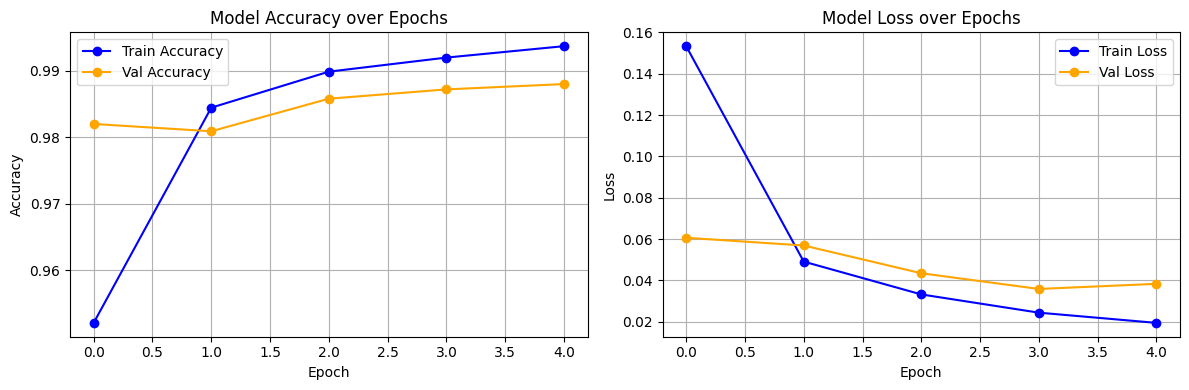

In [9]:
# Plotting Training vs Validation Accuracy and Loss
plt.figure(figsize=(12, 4))

# --- Accuracy Plot ---
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange', marker='o')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# --- Loss Plot ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss', color='blue', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss',   color='orange', marker='o')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


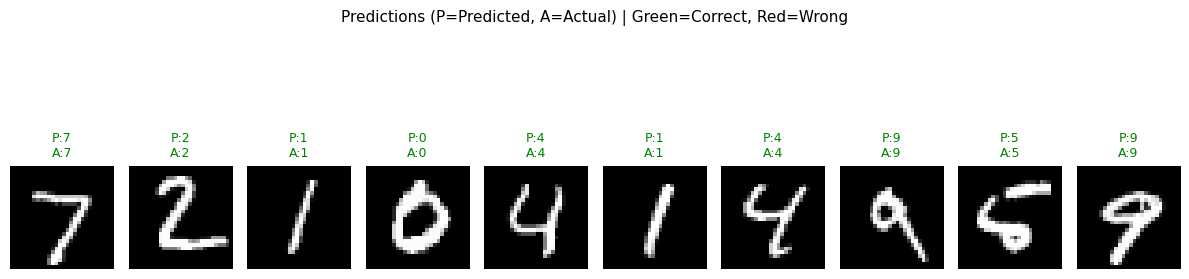

In [10]:
# Making predictions on the full test set
# model.predict() gives probability for each class (0-9)
y_pred_probs = model.predict(x_test)

# np.argmax() gives the index with highest probability = predicted digit
y_pred = np.argmax(y_pred_probs, axis=1)

# Displaying predictions for first 10 test images
plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')  # Show image
    
    predicted = y_pred[i]
    actual    = y_test[i]
    
    # If prediction matches actual label → green title, else red
    color = 'green' if predicted == actual else 'red'
    plt.title(f"P:{predicted}\nA:{actual}", color=color, fontsize=9)
    plt.axis('off')

plt.suptitle("Predictions (P=Predicted, A=Actual) | Green=Correct, Red=Wrong", fontsize=11)
plt.tight_layout()
plt.show()

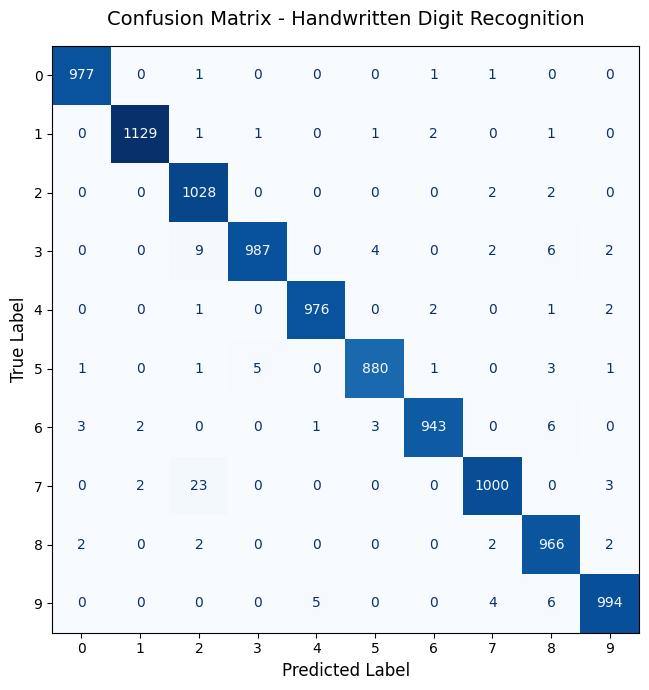

In [11]:
# Creating the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix using ConfusionMatrixDisplay
plt.figure(figsize=(9, 7))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=list(range(10)))
disp.plot(cmap='Blues', ax=plt.gca(), colorbar=False)

plt.title('Confusion Matrix - Handwritten Digit Recognition', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

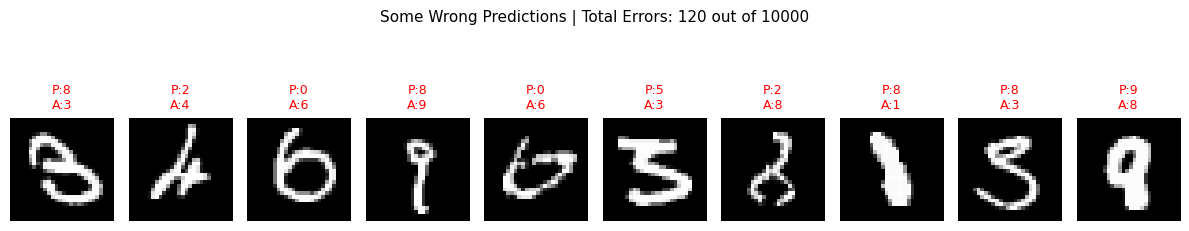

In [12]:
# Let's also display a few images the model got WRONG
# This helps understand where the model makes mistakes

wrong_indices = np.where(y_pred != y_test)[0]  # Indices where prediction was wrong

plt.figure(figsize=(12, 3))

for i in range(min(10, len(wrong_indices))):
    idx = wrong_indices[i]
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"P:{y_pred[idx]}\nA:{y_test[idx]}", color='red', fontsize=9)
    plt.axis('off')

plt.suptitle(f"Some Wrong Predictions | Total Errors: {len(wrong_indices)} out of 10000", fontsize=11)
plt.tight_layout()
plt.show()